In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHAPTER 6 — EGO Convergence & Adaptive Iteration Analysis
# Uses smt.applications.EGO with heatsink.txt data
# ═══════════════════════════════════════════════════════════════════════════════


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

from smt.applications import EGO
from smt.design_space import DesignSpace
from smt.surrogate_models import KRG
from scipy.interpolate import RBFInterpolator
from scipy.stats import norm

os.makedirs('chapter6_figs', exist_ok=True)
print("Imports OK")


Imports OK


In [3]:
data = np.loadtxt("/Users/dekoszero/Desktop/3rd year/Individual Engineering Project - MECH3890/coding/Raw Data/heat sink/heatsink.txt")

G1 = data[:, 0:1]
G2 = data[:, 1:2]
TR = data[:, 2:3]
PD = data[:, 3:4]

G1_min, G1_max = G1.min(), G1.max()
G2_min, G2_max = G2.min(), G2.max()

G1_n = (G1 - G1_min) / (G1_max - G1_min)
G2_n = (G2 - G2_min) / (G2_max - G2_min)

X_all = np.hstack([G1_n, G2_n])   # (n, 2)
Y_TR  = TR                          # (n, 1)
Y_PD  = PD                          # (n, 1)

xlimits      = np.array([[0., 1.], [0., 1.]])
design_space = DesignSpace(xlimits, seed=42)

n = X_all.shape[0]
print(f"Loaded {n} points from heatsink.txt")
print(f"G1 range : [{G1.min():.4f}, {G1.max():.4f}]")
print(f"G2 range : [{G2.min():.4f}, {G2.max():.4f}]")
print(f"TR range : [{TR.min():.6f}, {TR.max():.6f}]")
print(f"PD range : [{PD.min():.4f}, {PD.max():.4f}]")


Loaded 30 points from heatsink.txt
G1 range : [0.4000, 1.0000]
G2 range : [0.4000, 1.0000]
TR range : [0.161879, 0.247269]
PD range : [12553.0800, 38679.5700]


In [4]:
# DOE size = half the dataset (floor), rest forms the oracle pool
n_doe = n // 2

np.random.seed(42)
doe_idx = np.random.choice(n, size=n_doe, replace=False)

xdoe    = X_all[doe_idx]
ydoe_TR = Y_TR[doe_idx]
ydoe_PD = Y_PD[doe_idx]

# RBF interpolator spans the full dataset as the high-fidelity oracle
rbf_TR = RBFInterpolator(X_all, Y_TR.ravel(), kernel='thin_plate_spline')
rbf_PD = RBFInterpolator(X_all, Y_PD.ravel(), kernel='thin_plate_spline')

def oracle_TR(x):
    return rbf_TR(np.atleast_2d(x)).reshape(-1, 1)

def oracle_PD(x):
    return rbf_PD(np.atleast_2d(x)).reshape(-1, 1)

print(f"DOE: {n_doe} pts  |  Oracle pool: {n - n_doe} pts")


DOE: 15 pts  |  Oracle pool: 15 pts


In [6]:
N_ITER = n - n_doe   # use remaining points as iteration budget
SEED   = 42

ego_TR = EGO(
    n_iter    = N_ITER,
    criterion = 'EI',
    xdoe      = xdoe,
    ydoe      = ydoe_TR,
    surrogate = KRG(design_space=design_space, print_global=False),
    n_start   = 20,
    seed      = SEED,
)

x_opt_TR, y_opt_TR, _, x_data_TR, y_data_TR = ego_TR.optimize(fun=oracle_TR)
print(f"TR optimum : TR = {y_opt_TR.item():.6f} K/W  at x_norm = {x_opt_TR.ravel()}")

# Denormalise optimal point back to physical units
G1_opt_TR = x_opt_TR.ravel()[0] * (G1_max - G1_min) + G1_min
G2_opt_TR = x_opt_TR.ravel()[1] * (G2_max - G2_min) + G2_min
print(f"           : G1 = {G1_opt_TR:.4f},  G2 = {G2_opt_TR:.4f}")


TR optimum : TR = 0.162001 K/W  at x_norm = [0.97451677 1.        ]
           : G1 = 0.9847,  G2 = 1.0000


In [7]:
ego_PD = EGO(
    n_iter    = N_ITER,
    criterion = 'EI',
    xdoe      = xdoe,
    ydoe      = ydoe_PD,
    surrogate = KRG(design_space=design_space, print_global=False),
    n_start   = 20,
    seed      = SEED,
)

x_opt_PD, y_opt_PD, _, x_data_PD, y_data_PD = ego_PD.optimize(fun=oracle_PD)
print(f"PD optimum : PD = {y_opt_PD.item():.3f} Pa  at x_norm = {x_opt_PD.ravel()}")

# Denormalise optimal point back to physical units
G1_opt_PD = x_opt_PD.ravel()[0] * (G1_max - G1_min) + G1_min
G2_opt_PD = x_opt_PD.ravel()[1] * (G2_max - G2_min) + G2_min
print(f"           : G1 = {G1_opt_PD:.4f},  G2 = {G2_opt_PD:.4f}")


PD optimum : PD = 12553.080 Pa  at x_norm = [1. 0.]
           : G1 = 1.0000,  G2 = 0.4000


In [8]:
def best_trace(y_data, n_doe, n_iter):
    """Non-increasing best-found objective at each iteration."""
    return np.array([np.min(y_data[:n_doe + k]) for k in range(n_iter + 1)])

best_TR = best_trace(y_data_TR, n_doe, N_ITER)
best_PD = best_trace(y_data_PD, n_doe, N_ITER)
iters   = np.arange(N_ITER + 1)

def loo_rmse_trace(x_data, y_data, n_doe, n_iter):
    """
    LOO-RMSE at each EGO snapshot.
    Computes a full leave-one-out refit at every iteration step.
    """
    ds = DesignSpace(np.array([[0., 1.], [0., 1.]]), seed=0)
    rmse = []
    for k in range(n_doe, n_doe + n_iter + 1):
        xk, yk = x_data[:k], y_data[:k]
        errs = []
        for i in range(len(xk)):
            xi = np.delete(xk, i, axis=0)
            yi = np.delete(yk, i, axis=0)
            m = KRG(design_space=ds, print_global=False)
            m.set_training_values(xi, yi)
            m.train()
            pred = m.predict_values(xk[i:i+1]).ravel()[0]
            errs.append((pred - yk[i, 0])**2)
        rmse.append(np.sqrt(np.mean(errs)))
    return np.array(rmse)

print("Computing LOO-RMSE traces...")
loo_TR = loo_rmse_trace(x_data_TR, y_data_TR, n_doe, N_ITER)
loo_PD = loo_rmse_trace(x_data_PD, y_data_PD, n_doe, N_ITER)
print("Done.")


Computing LOO-RMSE traces...
Done.


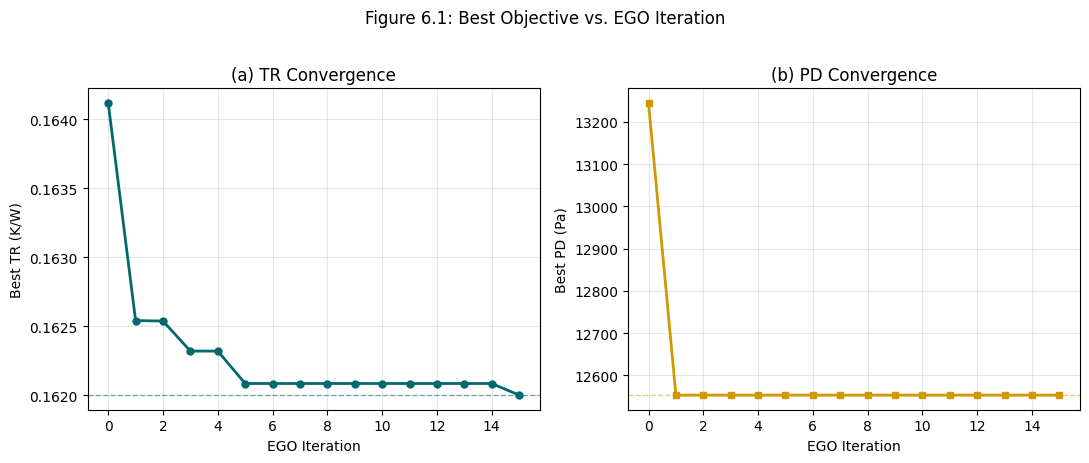

In [9]:
c = {'TR': '#01696f', 'PD': '#d19900'}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(iters, best_TR, 'o-', color=c['TR'], lw=2, ms=5)
axes[0].axhline(best_TR[-1], color=c['TR'], lw=1, ls='--', alpha=0.5)
axes[0].set(xlabel='EGO Iteration', ylabel='Best TR (K/W)',
            title='(a) TR Convergence')
axes[0].grid(alpha=0.3)

axes[1].plot(iters, best_PD, 's-', color=c['PD'], lw=2, ms=5)
axes[1].axhline(best_PD[-1], color=c['PD'], lw=1, ls='--', alpha=0.5)
axes[1].set(xlabel='EGO Iteration', ylabel='Best PD (Pa)',
            title='(b) PD Convergence')
axes[1].grid(alpha=0.3)

fig.suptitle('Figure 6.1: Best Objective vs. EGO Iteration', y=1.02)
plt.tight_layout()
plt.show()


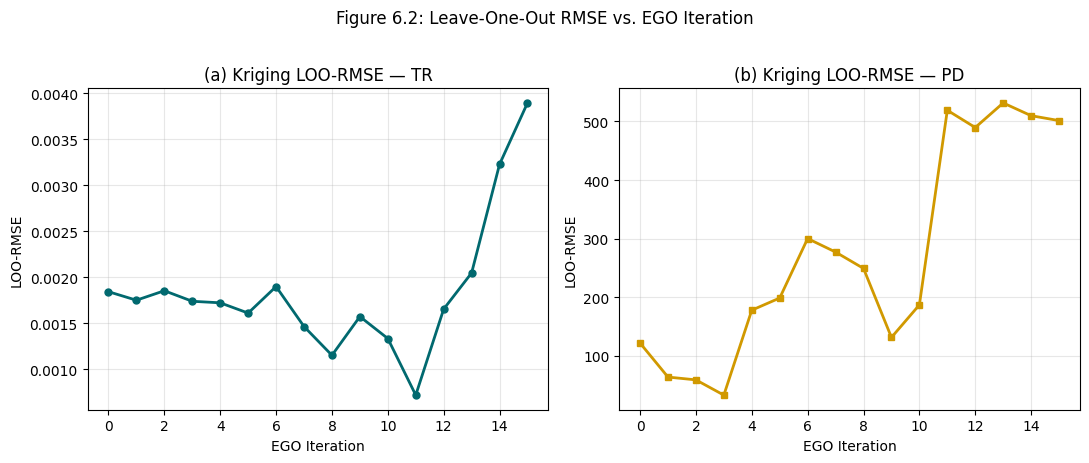

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(iters, loo_TR, 'o-', color=c['TR'], lw=2, ms=5)
axes[0].set(xlabel='EGO Iteration', ylabel='LOO-RMSE',
            title='(a) Kriging LOO-RMSE — TR')
axes[0].grid(alpha=0.3)

axes[1].plot(iters, loo_PD, 's-', color=c['PD'], lw=2, ms=5)
axes[1].set(xlabel='EGO Iteration', ylabel='LOO-RMSE',
            title='(b) Kriging LOO-RMSE — PD')
axes[1].grid(alpha=0.3)

fig.suptitle('Figure 6.2: Leave-One-Out RMSE vs. EGO Iteration', y=1.02)
plt.tight_layout()
plt.show()


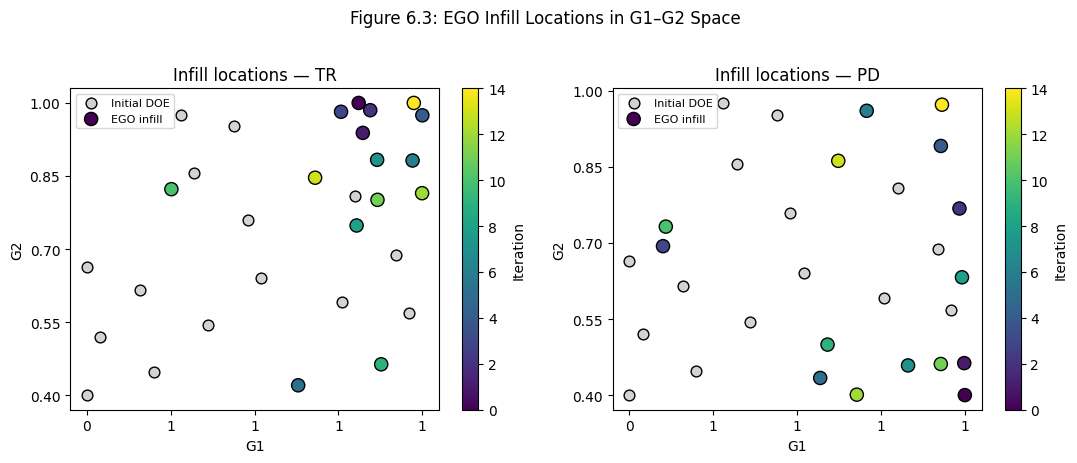

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, xd, lbl in [(axes[0], x_data_TR, 'TR'), (axes[1], x_data_PD, 'PD')]:
    ax.scatter(xd[:n_doe, 0], xd[:n_doe, 1],
               c='lightgray', edgecolors='k', s=60, zorder=3, label='Initial DOE')
    sc = ax.scatter(xd[n_doe:, 0], xd[n_doe:, 1],
                    c=np.arange(N_ITER), cmap='viridis',
                    edgecolors='k', s=90, zorder=4, label='EGO infill')
    plt.colorbar(sc, ax=ax, label='Iteration')
    # Denormalise tick labels to physical units
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([f'{v:.0f}' for v in
                        np.linspace(G1_min, G1_max, 5)])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([f'{v:.2f}' for v in
                        np.linspace(G2_min, G2_max, 5)])
    ax.set(xlabel='G1', ylabel='G2', title=f'Infill locations — {lbl}')
    ax.legend(fontsize=8)

fig.suptitle('Figure 6.3: EGO Infill Locations in G1–G2 Space', y=1.02)
plt.tight_layout()
plt.show()


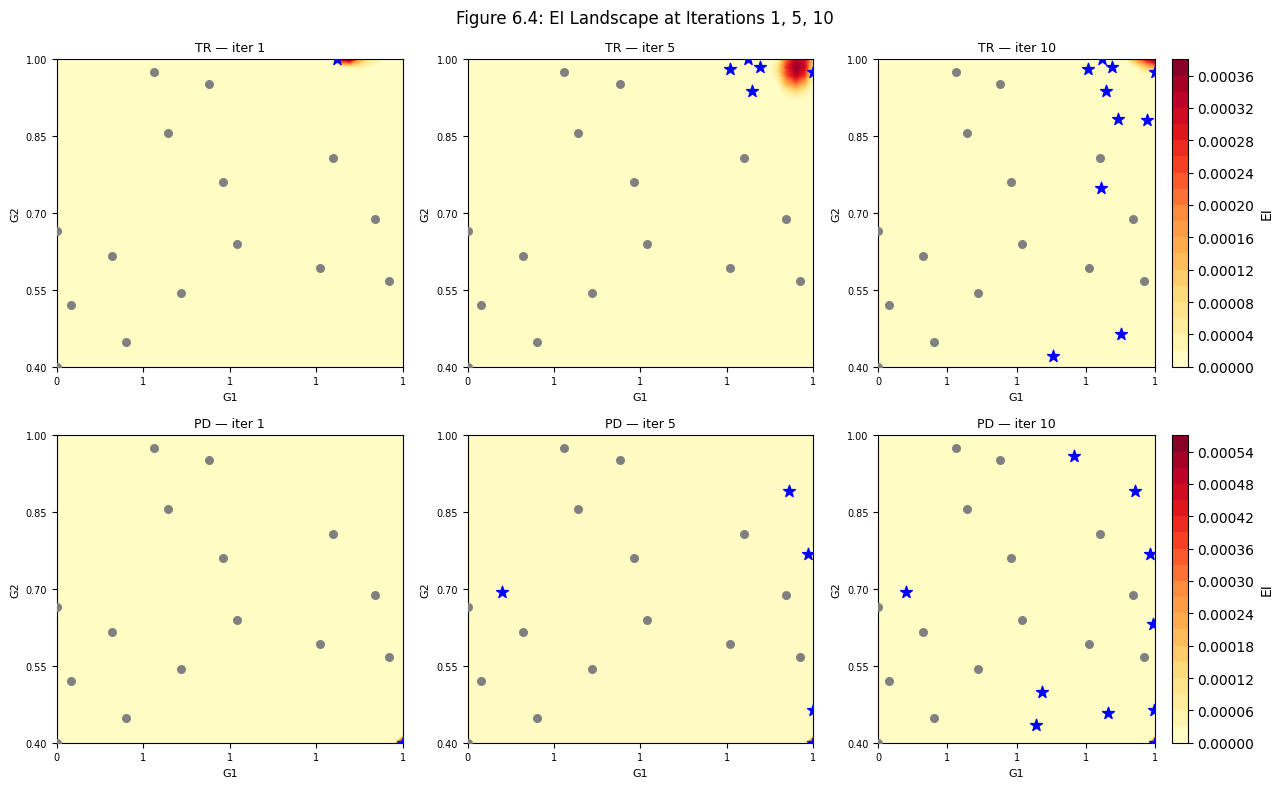

In [12]:
grid_res = 40
g1v = np.linspace(0, 1, grid_res)
g2v = np.linspace(0, 1, grid_res)
G1G, G2G = np.meshgrid(g1v, g2v)
X_grid = np.column_stack([G1G.ravel(), G2G.ravel()])

# Physical axis labels for contour plots
g1_ticks    = np.linspace(0, 1, 5)
g1_ticklbls = [f'{v:.0f}' for v in np.linspace(G1_min, G1_max, 5)]
g2_ticks    = np.linspace(0, 1, 5)
g2_ticklbls = [f'{v:.2f}' for v in np.linspace(G2_min, G2_max, 5)]

snaps = [1, 5, 10]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
ds2 = DesignSpace(xlimits, seed=0)

for col, snap in enumerate(snaps):
    for row, (xd, yd, lbl) in enumerate([
        (x_data_TR, y_data_TR, 'TR'),
        (x_data_PD, y_data_PD, 'PD')
    ]):
        k = n_doe + snap
        xk, yk = xd[:k], yd[:k]
        krg = KRG(design_space=ds2, print_global=False)
        krg.set_training_values(xk, yk)
        krg.train()

        mu  = krg.predict_values(X_grid)
        var = np.maximum(krg.predict_variances(X_grid), 0)
        sig = np.sqrt(var)
        f_min = yk.min()
        z  = (f_min - mu) / (sig + 1e-12)
        ei = np.maximum((f_min - mu)*norm.cdf(z) + sig*norm.pdf(z), 0)
        ei = ei.reshape(grid_res, grid_res)

        ax = axes[row, col]
        cf = ax.contourf(G1G, G2G, ei, levels=20, cmap='YlOrRd')
        ax.scatter(xk[:n_doe, 0], xk[:n_doe, 1], c='gray', s=30, zorder=3)
        ax.scatter(xk[n_doe:,  0], xk[n_doe:,  1], c='blue', marker='*', s=80, zorder=4)
        if col == 2:
            plt.colorbar(cf, ax=ax, label='EI')
        ax.set_xticks(g1_ticks); ax.set_xticklabels(g1_ticklbls, fontsize=7)
        ax.set_yticks(g2_ticks); ax.set_yticklabels(g2_ticklbls, fontsize=7)
        ax.set_title(f'{lbl} — iter {snap}', fontsize=9)
        ax.set_xlabel('G1', fontsize=8)
        ax.set_ylabel('G2', fontsize=8)

fig.suptitle('Figure 6.4: EI Landscape at Iterations 1, 5, 10')
plt.tight_layout()
plt.show()


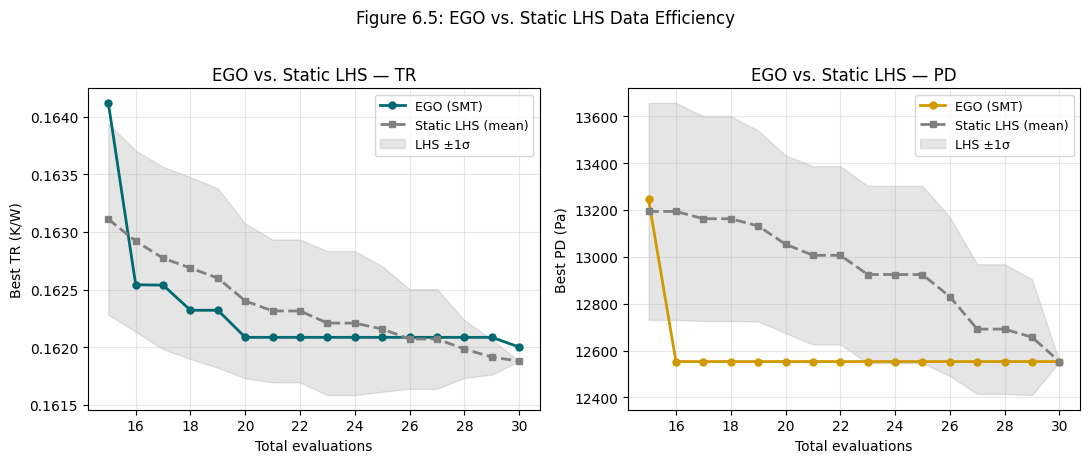


Table 6.1 — Convergence Summary
  Metric                         Value
  Dataset size (n)               30
  Initial DOE pts                15
  EGO iterations                 15
  Total evaluations              30
  Initial best TR (K/W)          0.164119
  Final best TR (K/W)            0.162001
  TR improvement (%)             1.3
  Initial best PD (Pa)           13244.67
  Final best PD (Pa)             12553.08
  PD improvement (%)             5.2
  Initial LOO-RMSE TR            0.001842
  Final LOO-RMSE TR              0.003895
  TR RMSE reduction (%)          -111.5
  Initial LOO-RMSE PD            121.3486
  Final LOO-RMSE PD              501.5501
  PD RMSE reduction (%)          -313.3


In [13]:
np.random.seed(99)
n_boot = 20
lhs_TR = np.zeros((n_boot, N_ITER + 1))
lhs_PD = np.zeros((n_boot, N_ITER + 1))

for b in range(n_boot):
    perm = np.random.permutation(n)
    for ki, k in enumerate(range(n_doe, n_doe + N_ITER + 1)):
        idx = perm[:k]
        lhs_TR[b, ki] = Y_TR[idx].min()
        lhs_PD[b, ki] = Y_PD[idx].min()

total_evals = np.arange(n_doe, n_doe + N_ITER + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, ego_b, lhs_m, lhs_s, lbl, unit, col in [
    (axes[0], best_TR, lhs_TR.mean(0), lhs_TR.std(0), 'TR', 'K/W', c['TR']),
    (axes[1], best_PD, lhs_PD.mean(0), lhs_PD.std(0), 'PD', 'Pa',  c['PD']),
]:
    ax.plot(total_evals, ego_b, 'o-', color=col, lw=2, ms=5, label='EGO (SMT)')
    ax.plot(total_evals, lhs_m, 's--', color='gray', lw=2, ms=5, label='Static LHS (mean)')
    ax.fill_between(total_evals, lhs_m - lhs_s, lhs_m + lhs_s,
                    color='gray', alpha=0.2, label='LHS ±1σ')
    ax.set(xlabel='Total evaluations', ylabel=f'Best {lbl} ({unit})',
           title=f'EGO vs. Static LHS — {lbl}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Figure 6.5: EGO vs. Static LHS Data Efficiency', y=1.02)
plt.tight_layout()
plt.show()

# ── Table 6.1: Convergence Summary ────────────────────────────────────────────
import csv

rows = [
    ['Metric', 'Value'],
    ['Dataset size (n)', n],
    ['Initial DOE pts', n_doe],
    ['EGO iterations', N_ITER],
    ['Total evaluations', n_doe + N_ITER],
    ['Initial best TR (K/W)', f'{best_TR[0]:.6f}'],
    ['Final best TR (K/W)',   f'{best_TR[-1]:.6f}'],
    ['TR improvement (%)',    f'{100*(best_TR[0]-best_TR[-1])/abs(best_TR[0]):.1f}'],
    ['Initial best PD (Pa)',  f'{best_PD[0]:.2f}'],
    ['Final best PD (Pa)',    f'{best_PD[-1]:.2f}'],
    ['PD improvement (%)',    f'{100*(best_PD[0]-best_PD[-1])/abs(best_PD[0]):.1f}'],
    ['Initial LOO-RMSE TR',   f'{loo_TR[0]:.6f}'],
    ['Final LOO-RMSE TR',     f'{loo_TR[-1]:.6f}'],
    ['TR RMSE reduction (%)', f'{100*(loo_TR[0]-loo_TR[-1])/loo_TR[0]:.1f}'],
    ['Initial LOO-RMSE PD',   f'{loo_PD[0]:.4f}'],
    ['Final LOO-RMSE PD',     f'{loo_PD[-1]:.4f}'],
    ['PD RMSE reduction (%)', f'{100*(loo_PD[0]-loo_PD[-1])/loo_PD[0]:.1f}'],
]

print("\nTable 6.1 — Convergence Summary")
for r in rows:
    print(f"  {r[0]:<30} {r[1]}")
